In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, '..')
from FAR.utils.measure import Measure, ClusterProcessor, Binning
from FAR.utils.read import LogitToStat, RecoveryData, DataProcessor, Merge
from FAR.utils.predict import predictFeatures
from FAR.utils.utilities import rename_columns, getFARCatalog, remove_little_dogs, rename_data
from FAR.utils.plot import Plotting as pl
from src.torch_utils import load_model, predictions
from sklearn import metrics
import matplotlib.pyplot as plt
import torch
from gwpy.timeseries import TimeSeries
from itertools import product
import math
import pickle
from matplotlib.colors import LinearSegmentedColormap, Normalize
import time
from matplotlib.ticker import ScalarFormatter
import re
import os
np.set_printoptions(precision=6, suppress=True)
#pd.options.mode.chained_assignment = None
pd.set_option('display.float_format', '{:.3f}'.format)


path = '/data/gravwav/lopezm/Projects/GlitchBank/'
path_store = path + 'runs/background/results/'
timeslides_file = 'git_new/computational-aspects-of-machine-learning-project-3/FAR/timeslides_proper.csv'
ifos = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
t_searches = [0.561999936580416, 0.673738299086758, 0.6958418315575849, 0.5619617579908676]
merge = Merge(path_store, path + timeslides_file)
darker_colors = ['indigo', 'darkgoldenrod', 'darkcyan', 'dimgray']
#colors = ['mediumorchid','cornflowerblue', 'hotpink', 'mediumseagreen']
colors = ['mediumpurple', 'goldenrod', 'mediumturquoise', 'grey']
t_searches = [0.561999936580416, 0.673738299086758, 0.6958418315575849, 0.5619617579908676]

In [3]:
def computeCounts(tmp, ifo, bins, ycol, p_star):
    
    TPR, yerr, mean_var, xerr = [], [], [], []
    for b in range(len(bins) - 1):

        if bins[b + 1] != bins[-1]:
            select = tmp[(tmp[ycol] >= bins[b]) & (tmp[ycol] < bins[b + 1])]
        else:
            print(b)
            select = tmp[tmp[ycol] >= bins[-1]]
        
        tp, p, _, _ = Measure.TPR(select, ifo, p_star=p_star)
        if bins[b] >= 13000: print(bins[b], tp/ p, tp, p)
        if p > 0:
            mean_var.append(np.mean(select[ycol]))
            xerr.append(3 * np.std(select[ycol]) / p)
            TPR.append(tp / p)
            #yerr.append(np.sqrt((tp/p)*(1-tp/p) / (p))) Binomial distribution
            yerr.append(np.sqrt(tp)/p)
        else:
            mean_var.append(np.nan)
            xerr.append(np.nan)
            TPR.append(np.nan)
            yerr.append(np.nan)

    return TPR, yerr, mean_var, xerr

def process_column(df, column_name, ifo):
    # Function to convert string to list of floats
    def string_to_float_list(input_string):
        if isinstance(input_string, np.ndarray):
            # Apparently some data does not need 
            # To transform to float... FIXME
            numbers_as_floats = input_string
            return numbers_as_floats
        if type(input_string) is float:
            # For injections sometimes we do not find the 
            # signal
            numbers_as_floats = [np.nan]
            return numbers_as_floats
        else:
            cleaned_string = input_string.strip('[]')
            numbers_as_strings = re.findall(r'[-+]?\d*\.\d+e[+-]?\d+|\d+\.\d+|\d+', cleaned_string)
            numbers_as_floats = [float(number) for number in numbers_as_strings]
            return numbers_as_floats

    # Function to extract the first and second values
    def extract_first_and_second(values):
        first = values[0] if len(values) > 0 else None
        second = values[1] if len(values) > 1 else None
        return first, second

    # Apply the function to convert strings to lists of floats
    df[f'feature_{ifo}_new'] = df[column_name].apply(string_to_float_list)

    # Apply the function and expand the result into two columns
    df[[f'SNR_av_{ifo}', f'Chisq_av_{ifo}']] = df[f'feature_{ifo}_new'].apply(extract_first_and_second).apply(pd.Series)

    # Drop the intermediate column if no longer needed
    df.drop(columns=[f'feature_{ifo}_new'], inplace=True)

    return df

def plotDistandSNR(datas, var, ifos, colors, t_searches,
                   new_stat=False, epsilon=1e-4, FAR=0.1, ptime='HLV'):

    # Define variables
    bins_dist = np.arange(0, 14000, 1000)
    bins_snr = np.concatenate([np.arange(0, 9), np.arange(10, 19, 2), np.arange(20, 55, 5)])
    
    if var == 'SNR': bins, xlabel = bins_snr, 'Injected SNR'
    elif var == 'distance': bins, xlabel = bins_dist, r'Luminosity distance $D_{L}$ (Mpc)'

    vars, TPRs = [], []
    for data, ifo, color, t_search in zip(datas, ifos, colors, t_searches): 

        t_bkg, bkg = merge.mergeTriggers(ifo.replace('1', ""), ptime, new_stat=new_stat) # FIXME

        if len(ifo) == 4:
            ifo1, ifo2 = ifo[:2], ifo[2:]
            
            if new_stat:
                print('new_stat')
                # bkg = process_column(bkg, 'feature_'+ifo1, ifo1)
                # bkg = process_column(bkg, 'feature_'+ifo2, ifo2)

                stat1 = bkg[f'Pinj_{ifo1}'] / (bkg[f'Chisq_max_{ifo1}'] / bkg[f'SNR_max_{ifo1}']**2)
                stat2 = bkg[f'Pinj_{ifo2}'] / (bkg[f'Chisq_max_{ifo2}'] / bkg[f'SNR_max_{ifo2}']**2)
                bkg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
                bkg['rank_stat_'+ifo1+ifo2] = bkg['barPinj']

                # data = process_column(data, 'feature_'+ifo1, ifo1)
                # data = process_column(data, 'feature_'+ifo2, ifo2)
                
                stat1 = data[f'Pinj_{ifo1}'] / (data[f'Chisq_max_{ifo1}'] / data[f'SNR_max_{ifo1}']**2)
                stat2 = data[f'Pinj_{ifo2}'] / (data[f'Chisq_max_{ifo2}'] / data[f'SNR_max_{ifo2}']**2)
                data['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
                data['rank_stat_'+ifo1+ifo2] = data['barPinj'] 
            else:
                stat1 = bkg[f'Pinj_{ifo1}']
                stat2 = bkg[f'Pinj_{ifo2}']
                bkg['barPinj'] = Measure.harmonic2coinc(stat1, stat2)
                bkg = Measure.prob2stat(bkg, ifo1+ifo2, col='barPinj')

            data['injSNR' + ifo] = np.sqrt(data['injSNR'+ifo[:2]]**2 + data['injSNR'+ ifo[2:]]**2)
 
        x, y_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=FAR)
        print(ifo, p_star)
        if xlabel == 'Injected SNR': ycol = 'injSNR'+ifo
        else: ycol = 'Distance'

        TPR, yerr, mean_var, xerr = computeCounts(data, ifo, bins, ycol, p_star)

        vars.append(mean_var)
        TPRs.append(TPR)
        if var == 'distance': 
            mean_var = np.asarray(mean_var)/1000.
            xerr = np.asarray(xerr)/1000.
        plt.plot(mean_var, np.asarray(TPR) + epsilon, label=ifo, c=color, alpha=0.8)
        plt.errorbar(mean_var, TPR, yerr=yerr, xerr=xerr,
                     fmt='o', capsize=2, color=color,
                     markerfacecolor=color, markersize=1, zorder=1)
        
        if xlabel == 'Injected SNR':
            plt.xscale('log')
            # Define the ticks you want on the x-axis
            ticks = [1, 5] + np.arange(10, 50, 10).tolist() + [70]
            plt.xticks(ticks)  # Set the ticks
            
            # Set custom tick labels corresponding to the tick positions
            plt.gca().set_xticklabels([str(tick) for tick in ticks])

            plt.xlim(1)
            
        #plt.yscale('log')
        #plt.yticks([epsilon, 0.01, 0.05, 0.10, 0.20, 0.30, 0.40],
        #           [0, 0.01, 0.05, 0.10, 0.20, 0.30, 0.40])
        #plt.ylim(epsilon, 0.4)
        plt.legend()
        plt.xlabel(xlabel), plt.ylabel('TPR')
        
        
    plt.legend(), plt.ylim((0, 1.05)), plt.grid(True)

    plt.savefig(f'{var}_new_stat.pdf')
    plt.show()
    return vars, TPRs

def plot_inverse_cumulative_histogram(data, bins=10):
    # Compute the histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Compute the cumulative sum of the counts in reverse order
    inverse_cumulative_counts = np.cumsum(counts[::-1])[::-1]

    return bin_edges, inverse_cumulative_counts

### Injections test

In [4]:
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/'
inj_hl = predictFeatures(path_inj + 'inj_coinc2_hl.csv', ['h1', 'l1'], 'inj')
inj_hv = predictFeatures(path_inj + 'inj_coinc2_hv.csv', ['h1', 'v1'], 'inj')
inj_lv = predictFeatures(path_inj + 'inj_coinc2_lv.csv', ['l1', 'v1'], 'inj')
inj_hlv = predictFeatures(path_inj + 'inj_coinc3_hlv.csv', ['h1', 'l1', 'v1'], 'inj')

inj_hl = rename_data('H1L1', inj_hl)
inj_hv = rename_data('H1V1', inj_hv)
inj_lv = rename_data('L1V1', inj_lv)
inj_hlv = rename_data('H1L1V1', inj_hlv)

# inj_hl.to_pickle(path_inj + 'inj_coinc2_pred_hl.csv')
# inj_hv.to_pickle(path_inj + 'inj_coinc2_pred_hv.csv')
# inj_lv.to_pickle(path_inj + 'inj_coinc2_pred_lv.csv')
# inj_hlv.to_pickle(path_inj + 'inj_coinc3_pred_hlv.csv')

98.72Acc_H1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2771epochs_10batches.pth


/data/gravwav/lopezm/Projects/GlitchBank/git_new/computational-aspects-of-machine-learning-project-3/FAR/../FAR/utils/read.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[label_stat].iloc[nonzero_idx] = stat[nonzero_idx, 0].numpy().tolist()


95.42Acc_L1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_3505epochs_10batches.pth


/data/gravwav/lopezm/Projects/GlitchBank/git_new/computational-aspects-of-machine-learning-project-3/FAR/../FAR/utils/read.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[label_stat].iloc[nonzero_idx] = stat[nonzero_idx, 0].numpy().tolist()


98.72Acc_H1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2771epochs_10batches.pth


...

/data/gravwav/lopezm/Projects/GlitchBank/git_new/computational-aspects-of-machine-learning-project-3/FAR/../FAR/utils/read.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[label_stat].iloc[nonzero_idx] = stat[nonzero_idx, 0].numpy().tolist()


95.42Acc_L1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_3505epochs_10batches.pth


/data/gravwav/lopezm/Projects/GlitchBank/git_new/computational-aspects-of-machine-learning-project-3/FAR/../FAR/utils/read.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[label_stat].iloc[nonzero_idx] = stat[nonzero_idx, 0].numpy().tolist()


99.05Acc_V1_ThreeLayers350_350_350Units_ReLU_CrossEntropyLoss_Adam_0.001lr_2382epochs_10batches.pth


/data/gravwav/lopezm/Projects/GlitchBank/git_new/computational-aspects-of-machine-learning-project-3/FAR/../FAR/utils/read.py:147: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[label_stat].iloc[nonzero_idx] = stat[nonzero_idx, 0].numpy().tolist()


In [5]:
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
inj_hl = pd.read_pickle(path_inj + 'inj_coinc2_pred_hl.csv')
inj_hv = pd.read_pickle(path_inj + 'inj_coinc2_pred_hv.csv')
inj_lv = pd.read_pickle(path_inj + 'inj_coinc2_pred_lv.csv')
inj_hlv = pd.read_pickle(path_inj + 'inj_coinc3_pred_hlv.csv')

### FIXME
columns_old = ['Class_V1',
       'Num triggers_V1', 'Cluster ID_V1', 'Cluster time_V1', 'SNR_max_V1',
       'Chisq_max_V1', 'Mass_1_max_V1', 'Mass_2_max_V1']

columns_new = [
       'Num triggers_V1', 'Cluster ID_V1', 'Cluster time_V1', 'SNR_max_V1',
       'Chisq_max_V1', 'Mass_1_max_V1', 'Mass_2_max_V1', 'Some_value']
# Create a dictionary mapping old column names to new column names
rename_dict = dict(zip(columns_old, columns_new))

# Rename the columns in the DataFrame
inj_hlv = inj_hlv.rename(columns=rename_dict)

In [19]:
with open(path_inj + f'clusters_h1.pkl', 'rb') as f:
    inj_c_h1 = pickle.load(f)
with open(path_inj + f'clusters_l1.pkl', 'rb') as f:
    inj_c_l1 = pickle.load(f)
with open(path_inj + f'clusters_v1.pkl', 'rb') as f:
    inj_c_v1 = pickle.load(f)

### Proper time

In [8]:
ifo = 'H1L1'
ptime = 'HLV'
#for ifo, ptime in zip(['H1L1', 'H1V1', 'L1V1'], ['HL_nV', 'HV_nL', 'LV_nH'])
t_bkg1, bkg1 = merge.mergeTriggers('H1L1', ptime, new_stat=True)
t_bkg2, bkg2 = merge.mergeTriggers('H1V1', ptime, new_stat=True)
t_bkg3, bkg3 = merge.mergeTriggers('L1V1', ptime, new_stat=True)
x1, y_obs1, _, _ = Measure.getFARandThreshold(bkg1, 'H1L1',
                                              t_bkg1, t_searches[0], maximum=350, FAR=0.1)
x2, y_obs2, _, _ = Measure.getFARandThreshold(bkg2, 'H1V1',
                                              t_bkg2, t_searches[1], maximum=350, FAR=0.1)
x3, y_obs3, _, _ = Measure.getFARandThreshold(bkg3, 'L1V1',
                                              t_bkg3, t_searches[2], maximum=350, FAR=0.1)


ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792


In [9]:
import numpy as np

def calculate_combined_far_multiple_arrays(far_values_list, Tb, far_star):
    """
    Calculate the combined False Alarm Rate (FAR_combined) based on the provided formula
    across multiple arrays of FAR values.
    
    Parameters:
    - far_values_list: List of arrays, where each array contains FAR values from different analyses or sources.
    - Tb: Total slide duration (T_b) for all slides performed.
    - far_star: The FAR* threshold value for which the combined FAR is calculated.
    
    Returns:
    - FAR_combined: The calculated combined False Alarm Rate.
    """
    # Initialize total count N_tot
    N_tot = 0
    
    # Loop through each array of FAR values
    for far_values in far_values_list:
        # Count the number of FAR values in this array that are less than or equal to FAR*
        N_tot += np.sum(far_values <= far_star)
    
    # Calculate FAR_combined
    FAR_combined = N_tot / Tb
    print(N_tot, Tb)
    
    return FAR_combined

# Example usage:
# Example list of uncombined FAR arrays from different analyses
far_values1 = y_obs1.copy()
far_values2 = y_obs2.copy()

# Combine them into a list
far_values_list = [far_values1, far_values2]

Tb = 1000.0  # Example total slide duration in seconds
far_star = 0.001  # Example FAR* threshold

# Calculate the combined FAR across all arrays
far_combined = calculate_combined_far_multiple_arrays(far_values_list, Tb, far_star)

print(f"Combined False Alarm Rate (FAR_combined): {far_combined}")


227778 1000.0
Combined False Alarm Rate (FAR_combined): 227.778


#### Some plottting

In [10]:
new_stat=True
for ifo in ifos:
    t_bkg, bkg = merge.mergeTriggers(ifo, 'HLV', new_stat=new_stat)
    print(ifo,len( bkg))

ptime HLV 1000
1792 1792
H1L1 17786
ptime HLV 1000
1792 1792
H1V1 25019
ptime HLV 1000
1792 1792
L1V1 20913
ptime HLV 1000
1792 1792
H1L1V1 2


In [18]:
def compute_rank_stat(pos, neg, ifo, method):
    """ Computes and updates the rank statistics based on the method. """
    
    def compute_stat(dataset, ifo1, ifo2, method):
        if method == "default":
            stat1 = dataset[f'Pinj_{ifo1}']
            stat2 = dataset[f'Pinj_{ifo2}']
        if method == "new":
            stat1 = dataset[f'Pinj_{ifo1}'] / (dataset[f'Chisq_max_{ifo1}'] / dataset[f'SNR_max_{ifo1}']**2)
            stat2 = dataset[f'Pinj_{ifo2}'] / (dataset[f'Chisq_max_{ifo2}'] / dataset[f'SNR_max_{ifo2}']**2)
        elif method == "simple":
            stat1 = dataset[f'SNR_max_{ifo1}']**2 / dataset[f'Chisq_max_{ifo1}']
            stat2 = dataset[f'SNR_max_{ifo2}']**2 / dataset[f'Chisq_max_{ifo2}']
        elif method == "complex":
            stat1 = dataset[f'SNR_max_{ifo1}'] / (0.5 * (1 + np.maximum(1, dataset[f'Chisq_max_{ifo1}']**2)))**(1/5)
            stat2 = dataset[f'SNR_max_{ifo2}'] / (0.5 *(1 + np.maximum(1, dataset[f'Chisq_max_{ifo2}']**2)))**(1/5)
        else:
            raise ValueError(f"Unknown method: {method}")
        return Measure.harmonic3coinc(stat1, stat2, [0])

    if len(ifo) == 4:
        ifo1, ifo2 = ifo[:2], ifo[2:]
        for dataset in [pos, neg]:
            dataset['barPinj'] = compute_stat(dataset, ifo1, ifo2, method)
            dataset[f'rank_stat_{ifo1}{ifo2}_{method}'] = dataset['barPinj']

    elif len(ifo) == 6:
        for dataset in [pos, neg]:
            if method == "default":
                stat1 = dataset[f'Pinj_H1'] 
                stat2 = dataset[f'Pinj_L1']
                stat3 = dataset[f'Pinj_V1']
            elif method == "new":
                stat1 = dataset[f'Pinj_H1'] / (dataset[f'Chisq_max_H1'] / dataset[f'SNR_max_H1']**2)
                stat2 = dataset[f'Pinj_L1'] / (dataset[f'Chisq_max_L1'] / dataset[f'SNR_max_L1']**2)
                stat3 = dataset[f'Pinj_V1'] / (dataset[f'Chisq_max_V1'] / dataset[f'SNR_max_V1']**2)
            elif method == "simple":
                stat1 = dataset[f'SNR_max_H1']**2 / dataset[f'Chisq_max_H1']
                stat2 = dataset[f'SNR_max_L1']**2 / dataset[f'Chisq_max_L1']
                stat3 = dataset[f'SNR_max_V1']**2 / dataset[f'Chisq_max_V1']
            elif method == "complex":
                stat1 = dataset[f'SNR_max_H1'] / (0.5 * (1 + np.maximum(1, dataset[f'Chisq_max_H1']**2)))**(1/5)
                stat2 = dataset[f'SNR_max_L1'] / (0.5 * (1 + np.maximum(1, dataset[f'Chisq_max_L1']**2)))**(1/5)
                stat3 = dataset[f'SNR_max_V1'] / (0.5 * (1 + np.maximum(1, dataset[f'Chisq_max_V1']**2)))**(1/5)
            else:
                raise ValueError(f"Unknown method: {method}")

            dataset['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
            dataset[f'rank_stat_H1L1V1_{method}'] = dataset['barPinj']


ptime HLV 1000
1792 1792
H1L1 (default): 9479.404794455731
ptime HLV 1000
1792 1792
H1L1 (simple): 9479.404794455731
ptime HLV 1000



KeyboardInterrupt



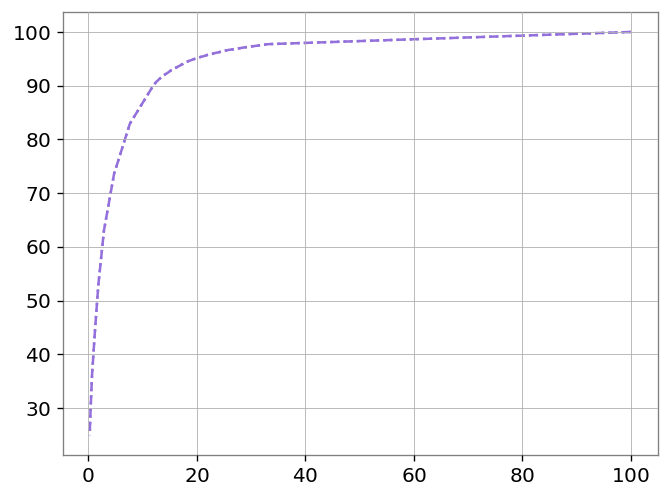

In [23]:
fig, axs = plt.subplots(1, 1, dpi=120)
ptime = 'HLV'

for c, ifo, t_search, inj in zip(colors, ifos, t_searches, [inj_hl, inj_hv, inj_lv, inj_hlv]):
    

    
    for method, linestyle in zip(["default", "new", "simple", "complex"],
                                 ["solid","--", ":", 'dashdot']):
        if "default": dt = np.concatenate([ np.zeros(1),
                                           np.arange(0.01, 0.9, 0.01), [0.9, 0.99, 0.999, 0.9999, 0.99999, 0.999999, 0.9999999, 0.99999999, 0.999999999]])
        else: dt = np.concatenate([np.arange(0, 20, 5), np.arange(20, 190, 10),
                         np.arange(190, 200, 10)])
        tprs, fprs = [], []
        t_bkg, bkg = merge.mergeTriggers(ifo, ptime)
        x, y_obs, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.1)
        pos, neg = inj.copy(), bkg.copy()
        
        compute_rank_stat(pos, neg, ifo, method)

        for d in dt:
            p_star = -np.log(1 - d + 1e-20)
            tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
            tpr = (tp / p) * 100
            fpr = Measure.FPR(neg, ifo, p_star=p_star)
            tprs.append(tpr)
            fprs.append(fpr)

        correction = (100 - max(fprs)) * max(tprs)
        auc = metrics.auc(fprs, tprs) + correction
        print(f"{ifo} ({method}):", auc)

        axs.plot(fprs, tprs, c=c, linestyle=linestyle, label=f"{ifo} ({method})")

axs.set_xlabel('FPR')
axs.set_ylabel('TPR')
axs.legend()

plt.tight_layout()
plt.savefig('roc_comparison_HLV_ptime.pdf')


ptime HLV 1000
1792 1792
H1L1 9281.540597328714
ptime HLV 1000
1792 1792
H1L1 9752.801934757776
ptime HLV 1000
1792 1792
H1L1 8795.276220195532
ptime HLV 1000
1792 1792
H1V1 9113.6927989704
ptime HLV 1000
1792 1792
H1V1 9716.734722204288
ptime HLV 1000
1792 1792
H1V1 8548.834033280407
ptime HLV 1000
1792 1792
L1V1 8843.806245907641
ptime HLV 1000
1792 1792
L1V1 9712.194890685321
ptime HLV 1000
1792 1792
L1V1 8686.165797675558
ptime HLV 1000
1792 1792
H1L1V1 9838.807555184707
ptime HLV 1000
1792 1792
H1L1V1 9877.87301828112
ptime HLV 1000
1792 1792
H1L1V1 0.0


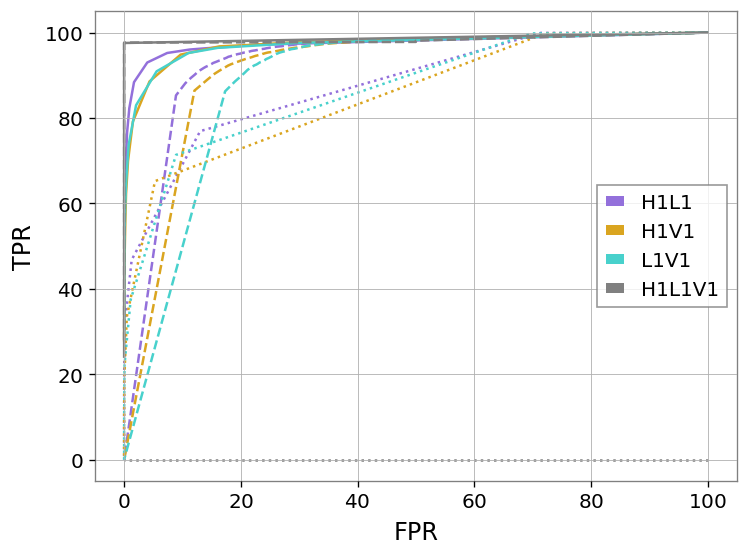

In [71]:
fig, axs = plt.subplots(1, 1, dpi=120)

ptime = 'HLV'
for c, ifo, t_search,  inj in zip(colors, ifos, t_searches, [inj_hl, inj_hv, inj_lv, inj_hlv]):
    new_stat=False
    dt = np.concatenate([np.zeros(1), np.arange(0.01, 0.9, 0.01),
                     np.asarray([0.9, 0.99, 0.999, 0.9999,
                                 0.99999, 0.999999,0.9999999,
                                 0.99999999, 0.999999999])])
    
    tprs, fprs = [], []
    t_bkg, bkg = merge.mergeTriggers(ifo, ptime)
    x, y_obs, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.1)
    pos, neg = inj.copy(), bkg.copy()
    
    # To test in tripple time
    if len(ifo) == 4:
        ifo1, ifo2 = ifo[:2], ifo[2:]

        stat1, stat2 = pos['Pinj_'+ifo1], pos['Pinj_'+ifo2]
        pos['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        pos['rank_stat_'+ifo1+ifo2] = pos['barPinj'] 

        stat1, stat2 = neg['Pinj_'+ifo1], neg['Pinj_'+ifo2]
        neg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        neg['rank_stat_'+ifo1+ifo2] = neg['barPinj'] 
    
        
    for d in dt:
        p_star = - np.log(1 - d + 1e-20)
        # We only consider post GstLAL
        tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
        tpr = tp /p * 100
        fpr = Measure.FPR(neg, ifo, p_star=p_star)
        tprs.append(tpr)
        fprs.append(fpr)

    correction = (100 - max(fprs))*max(tprs)
    auc = metrics.auc(fprs, tprs) + correction
    print(ifo, auc)
    axs.plot(fprs, tprs, c=c, linestyle='--')
    axs.set_xlabel('FPR'), axs.set_ylabel('TPR')

    new_stat=True
    dt = np.concatenate([np.arange(0, 20, 5), np.arange(20, 190, 10),
                         np.arange(190, 200, 10)])
    
    
    tprs, fprs = [], []
    t_bkg, bkg = merge.mergeTriggers(ifo, ptime, new_stat=new_stat) # FIXME
    x, y_obs, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.1)
    pos, neg = inj.copy(), bkg.copy()
    
    #if new_stat:
    if len(ifo) == 4:
        stat1 = pos[f'Pinj_{ifo1}'] / (pos[f'Chisq_max_{ifo1}'] / pos[f'SNR_max_{ifo1}']**2)
        stat2 = pos[f'Pinj_{ifo2}'] / (pos[f'Chisq_max_{ifo2}'] / pos[f'SNR_max_{ifo2}']**2)
        pos['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        pos['rank_stat_'+ifo1+ifo2] = pos['barPinj'] 

        stat1 = neg[f'Pinj_{ifo1}'] / (neg[f'Chisq_max_{ifo1}'] / neg[f'SNR_max_{ifo1}']**2)
        stat2 = neg[f'Pinj_{ifo2}'] / (neg[f'Chisq_max_{ifo2}'] / neg[f'SNR_max_{ifo2}']**2)
        neg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        neg['rank_stat_'+ifo1+ifo2] = neg['barPinj']
    if len(ifo) == 6:
        stat1 = pos[f'Pinj_H1'] / (pos[f'Chisq_max_H1'] / pos[f'SNR_max_H1']**2)
        stat2 = pos[f'Pinj_L1'] / (pos[f'Chisq_max_L1'] / pos[f'SNR_max_L1']**2)
        stat3 = pos[f'Pinj_V1'] / (pos[f'Chisq_max_V1'] / pos[f'SNR_max_V1']**2)
        pos['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
        pos['rank_stat_H1L1V1'] = pos['barPinj']

        stat1 = neg[f'Pinj_H1'] / (neg[f'Chisq_max_H1'] / neg[f'SNR_max_H1']**2)
        stat2 = neg[f'Pinj_L1'] / (neg[f'Chisq_max_L1'] / neg[f'SNR_max_L1']**2)
        stat3 = neg[f'Pinj_V1'] / (neg[f'Chisq_max_V1'] / neg[f'SNR_max_V1']**2)
        neg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
        neg['rank_stat_H1L1V1'] = neg['barPinj']

    for d in dt:
        p_star = d
        # We only consider post GstLAL
        tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
        tpr = tp /p * 100
        fpr = Measure.FPR(neg, ifo, p_star=p_star)
        tprs.append(tpr)
        fprs.append(fpr)

    correction = (100 - max(fprs))*max(tprs)
    auc = metrics.auc(fprs, tprs) + correction
    print(ifo, auc)
    axs.plot(fprs, tprs, c=c, label=ifo)
    axs.set_xlabel('FPR'), axs.set_ylabel('TPR'), axs.legend()

    tprs, fprs = [], []
    t_bkg, bkg = merge.mergeTriggers(ifo, ptime, new_stat=new_stat) # FIXME
    x, y_obs, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.1)
    pos, neg = inj.copy(), bkg.copy()
    
    if len(ifo) == 4:
        ifo1, ifo2 = ifo[:2], ifo[2:]
        stat1 = pos[f'SNR_max_{ifo1}'] / (0.5 * (1 + np.maximum(1, pos[f'Chisq_max_{ifo1}']**3)))**(1/5)
        stat2 = pos[f'SNR_max_{ifo2}'] / (0.5 * (1 + np.maximum(1, pos[f'Chisq_max_{ifo2}']**3)))**(1/5)

        # stat1 = pos[f'SNR_max_{ifo1}']**2/pos[f'Chisq_max_{ifo1}'] 
        # stat2 = pos[f'SNR_max_{ifo2}']**2/pos[f'Chisq_max_{ifo2}']
        pos['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        pos['rank_stat_'+ifo1+ifo2] = pos['barPinj'] 

        stat1 = neg[f'SNR_max_{ifo1}'] / (0.5 * (1 + np.maximum(1, neg[f'Chisq_max_{ifo1}']**3)))**(1/5)
        stat2 = neg[f'SNR_max_{ifo2}'] / (0.5 * (1 + np.maximum(1, neg[f'Chisq_max_{ifo2}']**3)))**(1/5)

        neg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        neg['rank_stat_'+ifo1+ifo2] = neg['barPinj']
    if len(ifo) == 6:
        stat1 = pos[f'SNR_max_H1'] / (0.5 * (1 + np.maximum(1, pos[f'Chisq_max_H1'])**3))**(1/5)
        stat1 = pos[f'SNR_max_L1'] / (0.5 * (1 + np.maximum(1, pos[f'Chisq_max_L1']**3)))**(1/5)
        stat1 = pos[f'SNR_max_V1'] / (0.5 * (1 + np.maximum(1, pos[f'Chisq_max_V1']**3)))**(1/5)

        pos['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
        pos['rank_stat_H1L1V1'] = pos['barPinj']

        stat1 = neg[f'SNR_max_H1'] / (0.5 * (1 + np.maximum(1, neg[f'Chisq_max_H1']**3)))**(1/5)
        stat1 = neg[f'SNR_max_L1'] / (0.5 * (1 + np.maximum(1, neg[f'Chisq_max_L1']**3)))**(1/5)
        stat1 = neg[f'SNR_max_V1'] / (0.5 * (1 + np.maximum(1, neg[f'Chisq_max_V1']**3)))**(1/5)

        neg['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
        neg['rank_stat_H1L1V1'] = neg['barPinj']
    
    for d in dt:
        p_star = d
        # We only consider post GstLAL
        tp, p, _, _ = Measure.TPR(pos, ifo, p_star=p_star)
        tpr = tp /p * 100
        fpr = Measure.FPR(neg, ifo, p_star=p_star)
        tprs.append(tpr)
        fprs.append(fpr)

    correction = (100 - max(fprs))*max(tprs)
    auc = metrics.auc(fprs, tprs) + correction
    print(ifo, auc)
    axs.plot(fprs, tprs, c=c, linestyle='dotted')
    axs.set_xlabel('FPR'), axs.set_ylabel('TPR'), axs.legend()


#plt.text(70, 90, r'$- \log{(1-\bar{P}_{inj})}$', bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.5'))
plt.tight_layout()
plt.savefig('roc_new_old_stat_HLV_ptime.pdf')

ptime HLV 1000
1792 1792
new_stat
H1L1 49.95
19
ptime HLV 1000
1792 1792
new_stat
H1V1 49.998
19
ptime HLV 1000
1792 1792
new_stat
L1V1 49.94
19
ptime HLV 1000
1792 1792
H1L1V1 0.0
19


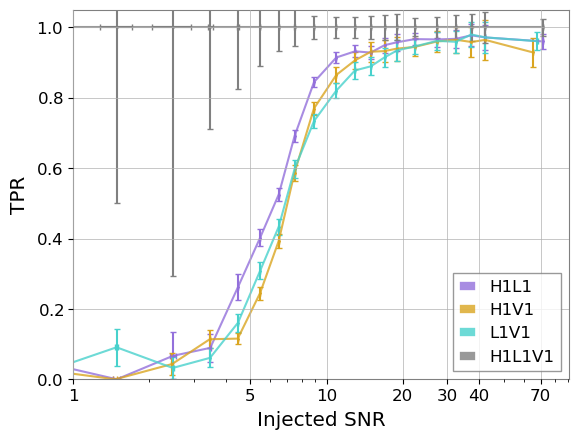

ptime HLV 1000


KeyboardInterrupt: 

In [27]:
snrs, tpr_snrs = plotDistandSNR([inj_hl, inj_hv, inj_lv, inj_hlv], 'SNR', 
                                ifos, colors, t_searches, new_stat=True)
dists, tpr_dists = plotDistandSNR([inj_hl, inj_hv, inj_lv, inj_hlv], 'distance',
                                  ifos, colors, t_searches, new_stat=True)

ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792


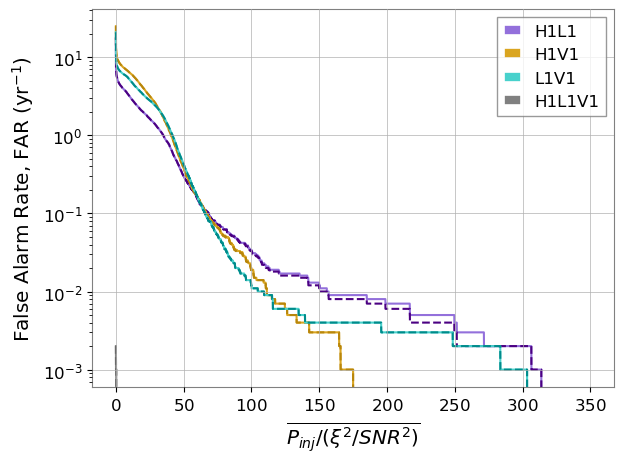

In [6]:
ptime = 'HLV'
for ifo, color, dark_color, t_search in zip(ifos, colors, darker_colors, t_searches):

    t_bkg, bkg = merge.mergeTriggers(ifo, ptime, new_stat=True) # FIXME
    bkg_ = remove_little_dogs(catalog, bkg, ifo, offset = 1)

    x1, y_obs1, _, _ = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, maximum=350, FAR=0.1)
    x2, y_obs2, _, _ = Measure.getFARandThreshold(bkg_, ifo, t_bkg, t_search, maximum=350, FAR=0.1)
    
    # Plot the inverse cumulative histogram
    plt.plot(x1, y_obs1, color=color, label=ifo)
    plt.plot(x2, y_obs2, alpha=1, linestyle='--', color=dark_color)
    plt.xlabel(r'$\overline{P_{inj}/(\xi^2/SNR^2)}$')
    plt.ylabel('False Alarm Rate, FAR (yr$^{-1}$)')
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    plt.savefig('ifar_new_stat.pdf')

In [7]:
ifo1,ifo2,ifo3,ifo4, ptime = 'H1L1', 'H1V1', 'L1V1', 'H1L1V1','HLV'
t_bkg1, bkg1 = merge.mergeTriggers(ifo1, ptime, new_stat=True)
t_bkg2, bkg2 = merge.mergeTriggers(ifo2, ptime, new_stat=True)
t_bkg3, bkg3 = merge.mergeTriggers(ifo3, ptime, new_stat=True)
t_bkg4, bkg4 = merge.mergeTriggers(ifo4, ptime, new_stat=True)
#bkg_ = remove_little_dogs(catalog, bkg, ifo, offset = 1)


ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792


In [46]:
data = pd.concat([bkg1['rank_stat_'+ifo1],
                  bkg2['rank_stat_'+ifo2],
                  bkg3['rank_stat_'+ifo3],
                  bkg4['rank_stat_'+ifo4]])
maximum = 350
bin_array = np.arange(0, maximum, 0.01)
N = np.sum(data.values[:, None] >= bin_array, axis=0)
iFAR = 1/(N/t_bkg1)
events = N*t_searches[3]/t_bkg1

/tmp/ipykernel_980363/3923072574.py:8: RuntimeWarning: divide by zero encountered in divide
  iFAR = 1/(N/t_bkg1)


34090
41563
41439
12677


/tmp/ipykernel_980363/3889174790.py:32: RuntimeWarning: divide by zero encountered in divide
  iFAR_ = 1/(N_/t_searches[3])


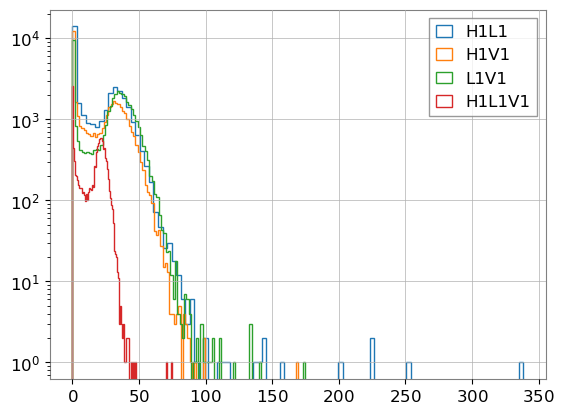

In [92]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'

zero_lags = []
for ifo in ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']:
    file = f'triggers{ifo.replace("1", "")}_zero_lag_run_eq_match1_hlv.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    print(len(tmp))
    if len(ifo) == 4:
        ifo1, ifo2 = ifo[:2], ifo[2:]
        
        stat1 = tmp[f'Pinj_{ifo1}'] / (tmp[f'Chisq_max_{ifo1}'] / tmp[f'SNR_max_{ifo1}']**2)
        stat2 = tmp[f'Pinj_{ifo2}'] / (tmp[f'Chisq_max_{ifo2}'] / tmp[f'SNR_max_{ifo2}']**2)
        tmp['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        tmp['rank_stat_'+ifo1+ifo2] = tmp['barPinj']
        plt.hist(tmp['rank_stat_'+ifo1+ifo2], bins=100, histtype='step', label=ifo)
        zero_lags.append(tmp['rank_stat_'+ifo1+ifo2])
    else:
        stat1 = tmp[f'Pinj_H1'] / (tmp[f'Chisq_max_H1'] / tmp[f'SNR_max_H1']**2)
        stat2 = tmp[f'Pinj_L1'] / (tmp[f'Chisq_max_L1'] / tmp[f'SNR_max_L1']**2)
        stat3 = tmp[f'Pinj_V1'] / (tmp[f'Chisq_max_V1'] / tmp[f'SNR_max_V1']**2)
        tmp['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
        tmp['rank_stat_'+ifo1+ifo2+ifo3] = tmp['barPinj']
        plt.hist(tmp['rank_stat_'+ifo1+ifo2+ifo3], bins=100, histtype='step', label=ifo)
        zero_lags.append(tmp['rank_stat_'+ifo1+ifo2+ifo3])

plt.legend()
plt.yscale('log')
data_  = pd.concat([zero_lags[0], zero_lags[1], zero_lags[2], zero_lags[3]])
maximum = 350
bin_array = np.arange(0, maximum, 0.01)
N_ = np.sum(data_.values[:, None] >= bin_array, axis=0)
iFAR_ = 1/(N_/t_searches[3])
events_ = N_*t_searches[3]/t_bkg1


Text(0, 0.5, 'Counts')

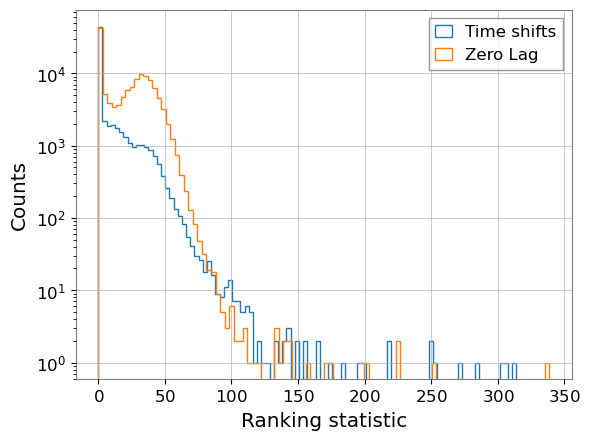

In [43]:
plt.hist(data, bins=100, histtype='step', label='Time shifts')
plt.hist(data_, bins=100, histtype='step', label='Zero Lag')
plt.legend()
plt.yscale('log')
plt.xlabel('Ranking statistic')
plt.ylabel('Counts')

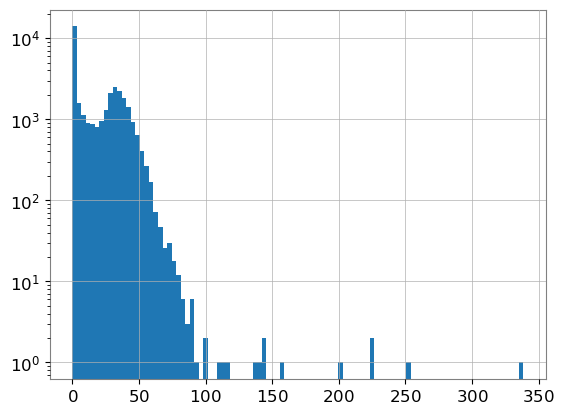

In [95]:
ifo = 'H1L1'
ifo1, ifo2 = 'H1', 'L1'
file = f'triggers{ifo.replace("1", "")}_zero_lag_run_eq_match1_hlv.csv'
tmp = pd.read_csv(path_zero_lag+file)
stat1 = tmp[f'Pinj_{ifo1}'] / (tmp[f'Chisq_max_{ifo1}'] / tmp[f'SNR_max_{ifo1}']**2)
stat2 = tmp[f'Pinj_{ifo2}'] / (tmp[f'Chisq_max_{ifo2}'] / tmp[f'SNR_max_{ifo2}']**2)
tmp['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
tmp['rank_stat_'+ifo1+ifo2] = tmp['barPinj']
plt.hist(tmp['rank_stat_'+ifo], bins=100)
plt.yscale('log')

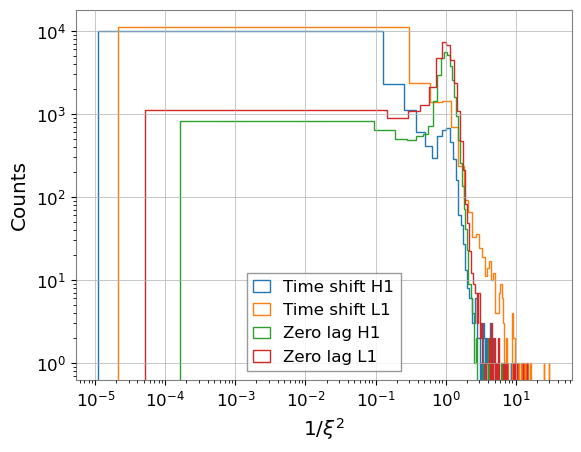

In [127]:
plt.hist(1/(bkg1['Chisq_max_H1']), bins=100, histtype='step', label='Time shift H1')
plt.hist(1/(bkg1['Chisq_max_L1']), bins=100, histtype='step', label='Time shift L1')
plt.hist(1/(tmp['Chisq_max_H1']), bins=100, histtype='step', label='Zero lag H1')
plt.hist(1/(tmp['Chisq_max_L1']), bins=100, histtype='step', label='Zero lag L1')
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'1/$\xi^2$')
plt.ylabel('Counts')#, plt.xlabel('Counts')
plt.legend()

In [218]:
ifo = 'H1'
reset = True
path_pred = '/data/gravwav/lopezm/Projects/GlitchBank/git_new/computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/'
unknown = pd.read_pickle(path_pred + f'pred_logs_unknown_eqmatch_reduced_{ifo.capitalize()}.csv')

if reset:
    # We reset the index to pass it to coincTriggers
    unknown = unknown.reset_index(drop=True)
    # Correction of clusters
    unknown['Cluster idx'] = unknown.index
maxcluster = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/time_slides/' + f'maxcluster_logs_{ifo.capitalize()}.csv')
maxcluster = maxcluster.sort_values(by='Cluster time')
maxcluster = maxcluster.loc[:, ~maxcluster.columns.str.contains('^Unnamed')]

unknown = pd.merge(unknown, maxcluster, on=['Cluster time', 'Cluster ID'], suffixes=("", "_max"))


Index(['feature', 'Num triggers', 'Cluster ID', 'Cluster time', 'Cluster idx',
       'Prob_0', 'Prob_1', 'Prob_2', 'Prob_3', 'Prob_4', 'Prob_5', 'Prob_6',
       'Pinj', 'rank_stat', 'ifo', 'SNR', 'Chisq', 'Trigger ID', 'Template ID',
       'Trigger time', 'Mass_1', 'Mass_2', 'Spin1z', 'Spin2z'],
      dtype='object')

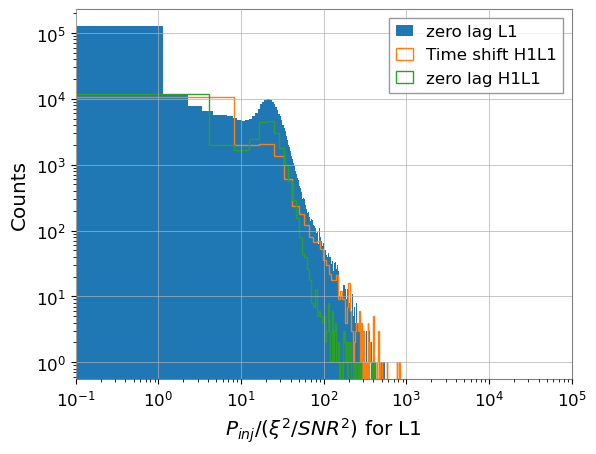

In [219]:
plt.hist(unknown['Pinj']/(unknown['Chisq']/unknown['SNR']**2), bins=1000, label='zero lag L1')
plt.hist(bkg1['Pinj_'+ifo]/(bkg1['Chisq_max_'+ifo]/bkg1['SNR_max_'+ifo]**2), bins=100, histtype='step', label='Time shift H1L1')
plt.hist(tmp['Pinj_'+ifo]/(tmp['Chisq_max_'+ifo]/tmp['SNR_max_'+ifo]**2), bins=100, histtype='step', label='zero lag H1L1')
plt.xscale('log'), 
plt.yscale('log')
plt.xlim(0.1, 1e5)
plt.ylabel('Counts'), plt.xlabel(r'$P_{inj}/(\xi^2/SNR^2)$ for L1')
plt.legend()
unknown.columns

In [217]:
len(bkg1), len(tmp)

(17786, 34090)

In [205]:
unknown['Cluster time old_L1'] = unknown['Cluster time'] 
len(pd.merge(tmp, unknown, on='Cluster time old_L1', how='inner')), len(bkg1), len(tmp), len(unknown)

(34090, 17786, 34090, 347811)

In [200]:
bkg1[]

354960

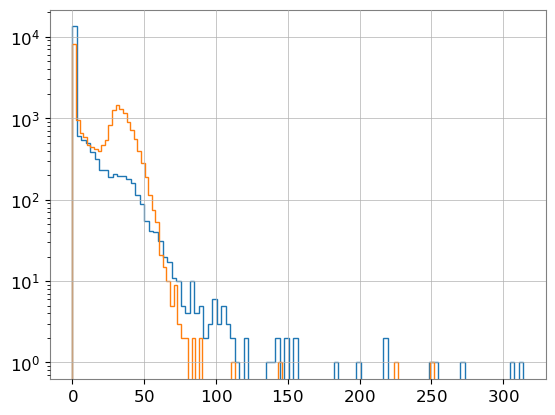

In [109]:
test = tmp[(tmp['Chisq_max_H1'] > 0.8) & (tmp['Chisq_max_H1'] < 1.3)]
plt.hist(bkg1['rank_stat_H1L1'], bins=100, histtype='step', label='Time shift H1')
plt.hist(test['rank_stat_H1L1'], bins=100, histtype='step', label='Time shift H1')
plt.yscale('log')

(None, None)

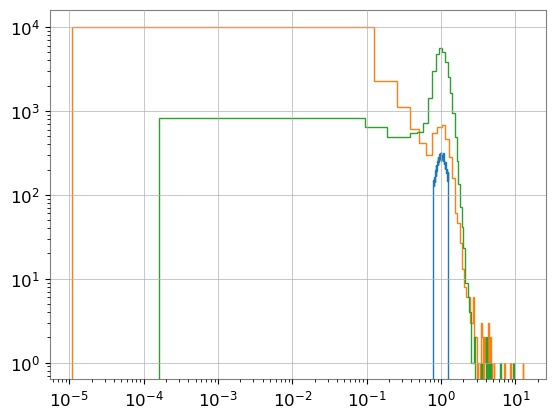

In [113]:
plt.hist(1/test['Chisq_max_H1'], bins=100, histtype='step')
plt.hist(1/bkg1['Chisq_max_H1'], bins=100, histtype='step')
plt.hist(1/tmp['Chisq_max_H1'], bins=100, histtype='step')
plt.yscale('log'), plt.xscale('log')

In [45]:
plt.loglog(iFAR_, N_/t_searches[3], color='darkorange', label='Zero lag')
plt.loglog(iFAR, N/t_bkg1, color='grey', label='Background')
#plt.loglog(iFAR_, events_, color='pink', label='Background')
for sigma, alpha in zip(np.arange(1, 6), 1 - np.linspace(0.75, 0.9, 5)):
    plt.fill_between(iFAR, 
                    N/t_bkg1 - sigma*np.sqrt(N/t_bkg1),
                    N/t_bkg1 + sigma*np.sqrt(N/t_bkg1), 
                                 color='grey', alpha=alpha)
plt.xlabel(r'Inverse False Alarm Rate, iFAR (yr$^{-1}$)')
plt.ylabel('Number of events')
plt.legend()

NameError: name 'iFAR_' is not defined

In [ ]:
N = bkg1['rank_stat_'+'H1L1'].copy()
iFAR = 1/(N/t_bkg1)
events = N*t_searches[0]/t_bkg1
plt.plot(iFAR)

# FARvsEvents(N, t_bkg, t_search, color, ax, i, j, label)

# binning = Binning()

# x, y, l, p = binning.fit_and_binning(data=bkg1['rank_stat_'+'H1L1'], maximum=350, rank=2)
# y_obs, ylabel = binning.yVar(y, l, 'events', t_bkg1, t_searches[0])

In [ ]:
ptime = 'HLV'
for ifo, color, dark_color, t_search in zip(ifos, colors, darker_colors, t_searches):

    t_bkg, bkg = merge.mergeTriggers(ifo, ptime, new_stat=True) # FIXME
    bkg_ = remove_little_dogs(catalog, bkg, ifo, offset = 1)
    print(ifo, len(bkg), len(bkg_), t_bkg)

    b1, i1 = plot_inverse_cumulative_histogram(bkg['rank_stat_'+ifo], bins=1000)
    b2, i2 = plot_inverse_cumulative_histogram(bkg_['rank_stat_'+ifo], bins=1000)
    
    # Plot the inverse cumulative histogram
    plt.plot(b1[:-1], i1, color=color, label=ifo)
    plt.plot(b2[:-1], i2, alpha=1, linestyle='--', color=dark_color)
    plt.xlabel(r'$\overline{P_{inj}/(\xi^2/SNR^2)}$')
    plt.ylabel('Inverse cumulative time shifts')
    plt.yscale('log')
    plt.legend()
    plt.tight_layout()
    #plt.savefig('inv_cum_new_stat.pdf')

In [ ]:
ifo = 'H1L1'
ifo1, ifo2 = ifo[:2], ifo[2:]
t_bkg, bkg = merge.mergeTriggers(ifo, new_stat=True)
bkg = bkg.sort_values(by='rank_stat_'+ifo, ascending=False)
with open('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/' + f'clusters_unknown_{ifo1.lower()}_reduced.pkl', 'rb') as f:
    cluster1 = pickle.load(f)
with open('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/' + f'clusters_unknown_{ifo2.lower()}_reduced.pkl', 'rb') as f:
    cluster2 = pickle.load(f)

In [ ]:
bkg[['Pinj_H1', 'Pinj_L1', 
     'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1',
     'rank_stat_'+ifo1+ifo2]].head(5)

In [ ]:
display(bkg.iloc[i][['Pinj_H1', 'Pinj_L1', 'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1']])

In [ ]:

for i in range(5):
    print(bkg.iloc[i]['Cluster time_'+ifo1], bkg.iloc[i]['Cluster time_'+ifo2])
    print(bkg.iloc[i]['Cluster time old_'+ifo1], bkg.iloc[i]['Cluster time old_'+ifo2])
    pl.plotSpect2coinc(ifo1, ifo2, bkg.iloc[i]['Cluster time old_'+ifo1],
                    bkg.iloc[i]['Cluster time old_'+ifo2])
    display(bkg.iloc[i][['Pinj_H1', 'Pinj_L1', 'SNR_max_H1', 'SNR_max_L1', 'Chisq_max_H1', 'Chisq_max_L1']])
    plt.scatter(cluster1[bkg.iloc[i]['Cluster idx_'+ifo1]]['Mass_1'],
                cluster1[bkg.iloc[i]['Cluster idx_'+ifo1]]['Mass_2'], s=1, label=ifo1)
    plt.scatter(cluster2[bkg.iloc[i]['Cluster idx_'+ifo2]]['Mass_1'], 
                cluster2[bkg.iloc[i]['Cluster idx_'+ifo2]]['Mass_2'], s=1, alpha=0.5, label=ifo2)
    plt.scatter(bkg.iloc[i]['Mass_1_max_'+ifo1], bkg.iloc[i]['Mass_2_max_'+ifo1],
                s=10, marker='*', alpha=0.5, label=ifo2, c='cornflowerblue')
    plt.scatter(bkg.iloc[i]['Mass_1_max_'+ifo2], bkg.iloc[i]['Mass_2_max_'+ifo2],
                s=10, marker='*', alpha=0.5, label=ifo2, c='darkorange')

    plt.xlabel('$m_1$'), plt.ylabel('$m_2$')
    plt.xscale('log'), plt.yscale('log')
    plt.legend()
    plt.show()

In [ ]:
for i in range(10):
    tmp1 = inj_c_h1[i]
    tmp2 = inj_c_l1[i]
    # display(tmp1)
    # display(tmp2)
    print(np.unique(tmp1['Cluster time'])[0], np.unique(tmp2['Cluster time'])[0], np.unique(tmp1['Cluster time'])[0] - np.unique(tmp2['Cluster time'])[0])
    plt.scatter(tmp1['Mass_1'], tmp1['Mass_2'], s=1)
    plt.scatter(tmp2['Mass_1'], tmp2['Mass_2'], alpha=0.5, s=1)
    plt.xscale('log'), plt.yscale('log')
    plt.grid(False)
    plt.show()

### Zero lag test

In [ ]:
%%time
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'

u_h1 = predictFeatures(path_inj + 'unknown_h1_reduced.csv', ['h1'], 'zero_lag')
u_l1 = predictFeatures(path_inj + 'unknown_l1_reduced.csv', ['l1'], 'zero_lag')
u_v1 = predictFeatures(path_inj + 'unknown_v1_reduced.csv', ['v1'], 'zero_lag')

In [ ]:
path_store_pred = '/data/gravwav/lopezm/Projects/GlitchBank/computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/'
u_h1.rename(columns=lambda col: rename_columns(col, '_h1', ''), inplace=True)
u_l1.rename(columns=lambda col: rename_columns(col, '_l1', ''), inplace=True)
u_v1.rename(columns=lambda col: rename_columns(col, '_v1', ''), inplace=True)

u_h1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_H1.csv')
u_l1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_L1.csv')
u_v1.to_pickle(path_store_pred + 'pred_logs_unknown_eqmatch_reduced_V1.csv')

### Time slides test

In [ ]:
path_store = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
path = '/data/gravwav/lopezm/Projects/GlitchBank/'
dp = DataProcessor(path + 'computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/', path + 'runs/zero_lag/', path + 'runs/injections')

start_time = time.time()
u_h1, uc_h1 = dp.LoadZeroLag('h1', reset=True)
u_l1, uc_l1 = dp.LoadZeroLag('l1', reset=True)
u_v1, uc_v1 = dp.LoadZeroLag('v1', reset=True)
end_time = time.time()

In [ ]:
def coincTriggers3(x, data_x, data_y, data_z, cluster_x, cluster_y, cluster_z, shift1=0, shift2=0, shift3=0, window=1):
        """
        Find coincident triggers between three data sets within a time window.

        Parameters:
        x (int): Index of the trigger in data_x.
        data_x (pd.DataFrame): DataFrame containing the first set of data.
        data_y (pd.DataFrame): DataFrame containing the second set of data.
        data_z (pd.DataFrame): DataFrame containing the third set of data.
        cluster_x (dict): Dictionary containing clusters for data_x.
        cluster_y (dict): Dictionary containing clusters for data_y.
        cluster_z (dict): Dictionary containing clusters for data_z.
        shift1 (float): Time shift for the first cluster.
        shift2 (float): Time shift for the second cluster.
        shift3 (float): Time shift for the third cluster.
        window (float): Time window for finding coincident triggers.

        Returns:
        tuple: Index x, index y, index z, and delta_t values if conditions are met; otherwise, returns None values.
        """
       
        # Directly access the value instead of using iloc
        cluster_time_x = data_x.at[x, 'Cluster time']

        # Vectorized condition check
        mask = (data_y['Cluster time'] >= cluster_time_x - window) & (data_y['Cluster time'] <= cluster_time_x + window)
        tmp_y = data_y[mask]

        mask = (data_z['Cluster time'] >= cluster_time_x - window) & (data_z['Cluster time'] <= cluster_time_x + window)
        tmp_z = data_z[mask]

        if (tmp_y.empty) or (tmp_z.empty):
            return x, None, None, None, None, None

        for i, j in product(range(len(tmp_y)), range(len(tmp_z))):
            y = tmp_y.index[i]
            z = tmp_z.index[j]
            #tx, ty, tz = cluster_time_x, tmp_y['Cluster time'].iloc[i], tmp_z['Cluster time'].iloc[j]
            #print(tx, ty, tx)
            cluster1, cluster2, cluster3 = cluster_x[x], cluster_y[y], cluster_z[z]
    
            # Check the length conditions
            if len(cluster1) < 10 or len(cluster2) < 10 or len(cluster3) < 10:
                return x, None, None, None, None, None

            tmp = mergeClusters3(cluster1, cluster2, cluster3, shift2=shift2, shift3=shift3)
            
            delta_t1, delta_t2, delta_t3 = tmp['Delta t_hl'].mean(), tmp['Delta t_hv'].mean(), tmp['Delta t_lv'].mean()
            if len(tmp) > 0:
                print(i, delta_t1, delta_t2, delta_t3)
            if (delta_t1 <= 0.015) and (delta_t2 <= 0.032) and (delta_t3 <= 0.031):
                # print(delta_t1, delta_t2, delta_t3)
                return x, y, z, delta_t1, delta_t2, delta_t3
    
        return x, None, None, None, None, None

def coincTriggers3(x, data_x, data_y, data_z, cluster_x, cluster_y, cluster_z, shift1=0, shift2=0, shift3=0, window=1):
    cluster_time_x = data_x.at[x, 'Cluster time']
    
    if data_x.at[x, 'Num triggers'] < 10:
        return x, None, None, None, None, None

    mask_y = (data_y['Cluster time'] >= cluster_time_x - window) & (data_y['Cluster time'] <= cluster_time_x + window)
    tmp_y = data_y[mask_y]

    mask_z = (data_z['Cluster time'] >= cluster_time_x - window) & (data_z['Cluster time'] <= cluster_time_x + window)
    tmp_z = data_z[mask_z]

    if tmp_y.empty or tmp_z.empty:
        return x, None, None, None, None, None
    
    tmp_y.reset_index(inplace=True)
    tmp_z.reset_index(inplace=True)

    results = []
    cluster1 = cluster_x[x]
    for _, row_y in tmp_y.iterrows():
        for _, row_z in tmp_z.iterrows():
            y = row_y['index']
            z = row_z['index']
            ty = row_y['Cluster time']
            tz = row_z['Cluster time']
            cluster2 = cluster_y[y]
            cluster3 = cluster_z[z]

            if len(cluster2) < 10 or len(cluster3) < 10:
                continue
            print(i, len(cluster1), len(cluster2), len(cluster3))

            tmp = mergeClusters3(cluster1, cluster2, cluster3, shift2=shift2, shift3=shift3)
            
            if len(tmp) > 0:
                delta_t1, delta_t2, delta_t3 = tmp['Delta t_hl'].mean(), tmp['Delta t_hv'].mean(), tmp['Delta t_lv'].mean()
                if (delta_t1 <= 0.015) and (delta_t2 <= 0.032) and (delta_t3 <= 0.031):
                    results.append((x, y, z, delta_t1, delta_t2, delta_t3))
    
    if results:
        return results[0]
    else:
        return x, None, None, None, None, None


def mergeClusters(cluster1, cluster2, suffixes, label, shift1=0, shift2=0):
        tmp = pd.merge(cluster1.drop_duplicates(subset=['Template ID']),
                       cluster2.drop_duplicates(subset=['Template ID']),
                       on=['Template ID'], how='inner', suffixes=suffixes)
        # if len(tmp) > 0:
        #     print('cluster', t1, t2, suffixes)
        #     print('trigger', shift1, shift2, (tmp['Trigger time' + suffixes[0]].values[0]+ shift1) - (tmp['Trigger time' + suffixes[1]].values[0]+ shift2))
        tmp[label] = np.abs((tmp['Trigger time' + suffixes[0]] + shift1)  - (tmp['Trigger time' + suffixes[1]] + shift2))
        #if tmp[label].mean() < 0.35:
        #    print(tmp[label].mean(), suffixes)
        return tmp

# def mergeClusters3(cluster1, cluster2, cluster3, shift2=0, shift3=0):
#         tmp = pd.merge(cluster1.drop_duplicates(subset=['Template ID']),
#                        cluster2.drop_duplicates(subset=['Template ID']),
#                        on=['Template ID'], how='inner', suffixes=['_h1', '_l1'])
#         if len(tmp) > 0: print('hl', len(tmp))
#         # This is a hack for '_v1' suffixes
#         cluster3 = cluster3.rename(columns={col: col + '_v1' if col != 'Template ID' else col for col in cluster3.columns})
#         tmp = pd.merge(tmp.drop_duplicates(subset=['Template ID']),
#                        cluster3.drop_duplicates(subset=['Template ID']),
#                        on=['Template ID'], how='inner', suffixes=['', '_v1'])
    
#         # We shift the clusters in time
#         tmp['Trigger time_l1'] = tmp['Trigger time_l1'] + shift2
#         tmp['Trigger time_v1'] = tmp['Trigger time_v1'] + shift3

#         # And calculate delta time
#         tmp['Delta t_hl'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_l1'])
#         tmp['Delta t_hv'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_v1'])
#         tmp['Delta t_lv'] = np.abs(tmp['Trigger time_l1'] - tmp['Trigger time_v1'])
#         # if len(tmp) > 0:
#         #     print(shift2, shift3)
#         #     print(tmp[['Trigger time_h1', 'Trigger time_l1', 'Trigger time_v1']])
#         #     print(tmp[['Delta t_hl', 'Delta t_hv', 'Delta t_lv']])
#         #     print(' ')
#         return tmp

def mergeClusters3(cluster1, cluster2, cluster3, shift2=0, shift3=0):
    # Drop duplicates before merging
    cluster1_unique = cluster1.drop_duplicates(subset=['Template ID'])
    cluster2_unique = cluster2.drop_duplicates(subset=['Template ID'])
    cluster3_unique = cluster3.drop_duplicates(subset=['Template ID'])
    # Merge cluster1 and cluster2
    tmp = pd.merge(cluster1_unique, cluster2_unique, on='Template ID', how='inner', suffixes=['_h1', '_l1'])
    print(cluster1_unique['Template ID'].values,cluster2_unique['Template ID'].values)
    print(np.intersect1d(cluster1_unique['Template ID'].values, cluster2_unique['Template ID'].values))
    if tmp.empty:
        return tmp

    # Rename columns in cluster3
    cluster3_unique = cluster3_unique.rename(columns={col: col + '_v1' if col != 'Template ID' else col for col in cluster3_unique.columns})

    # Merge with cluster3
    tmp = pd.merge(tmp, cluster3_unique, on='Template ID', how='inner')

    if tmp.empty:
        return tmp

    # Shift the clusters in time
    tmp['Trigger time_l1'] += shift2
    tmp['Trigger time_v1'] += shift3

    # Calculate delta time
    tmp['Delta t_hl'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_l1'])
    tmp['Delta t_hv'] = np.abs(tmp['Trigger time_h1'] - tmp['Trigger time_v1'])
    tmp['Delta t_lv'] = np.abs(tmp['Trigger time_l1'] - tmp['Trigger time_v1'])

    return tmp


In [ ]:
sl, sv = 0, 0
u_l1_ = dp.shiftedDataSet(u_l1, window=6)
u_v1_ = dp.shiftedDataSet(u_v1, window=12)
cp = ClusterProcessor()

In [ ]:
i = 1
start = time.time()
h4, l4, v4, t13, t23, t33 = coincTriggers3(i, u_h1, u_l1,
                                                  u_v1, uc_h1,
                                                  uc_l1, uc_v1, shift1=0, shift2=sl, shift3=sv, window=0.5)
print(h4, l4, v4, t13, t23, t33)
end = time.time()
print(end - start)

In [ ]:
H4, L4, V4, T13, T23, T33 = [], [], [], [], [], []
for i in range(len(u_h1)):
    #if i % 1000 == 0: print(i)
    print(i)
    start = time.time()
    h4, l4, v4, t13, t23, t33 = coincTriggers3(i, u_h1, u_l1,
                                                      u_v1, uc_h1,
                                                      uc_l1, uc_v1, shift1=0, shift2=sl, shift3=sv, window=0.5)
    end = time.time()
    #print(end - start)
    H4.append(h4); L4.append(l4); T13.append(t13)

### Zero lag coincidence

In [ ]:
ifo = 'H1L1'
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

for ifo in ifos[:-1]:
    t_bkg, bkg = merge.mergeTriggers(ifo) 
    
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    tmp = tmp.sort_values(by='rank_stat_'+ifo, ascending=False)
    print(len(bkg), len(tmp))

In [ ]:
!ls /data/gravwav/lopezm/Projects/GlitchBank/runs/background/results/ -l -t | head -10

In [ ]:
for ifo in ifos[:-1]:
    print(ifo)
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    
    path_time_slides = '/data/gravwav/lopezm/Projects/GlitchBank/runs/background/results/'
    file_ = f'triggers{ifo.replace("1", "")}_run_eq_match1_zero_background.csv'
    tmp_ = pd.read_csv(path_time_slides+file_)
    if ifo == 'H1V1':
        print(ifo, len(tmp), len(tmp_),
          (tmp['Cluster time old_'+ifo[:2]][1:].values == tmp_['Cluster time old_'+ifo[:2]].values).sum())
    else:
        print(ifo, len(tmp), len(tmp_),
          (tmp['Cluster time old_'+ifo[:2]].values == tmp_['Cluster time old_'+ifo[:2]].values).sum())


In [ ]:
print(len(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)])/ len(tmp))
plt.hist(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.hist(tmp['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.yscale('log')

In [ ]:
print(len(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)])/ len(bkg))
# plt.hist(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'],
#          bins=100, density=True, histtype='step', label='Background')
# plt.hist(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]['rank_stat_L1V1'], 
#          bins=100, density=True, histtype='step', label='Foreground')

plt.hist(bkg['rank_stat_L1V1'],
          bins=100, density=True, histtype='step', label='Background')
plt.hist(tmp['rank_stat_L1V1'], 
          bins=100, density=True, histtype='step', label='Foreground')

#plt.hist(bkg['rank_stat_L1V1'], bins=100, density=True, histtype='step')
plt.yscale('log')
plt.xlabel(r'$-log{(1-\bar{P}_{inj})}$'), plt.ylabel('Probability distribution')
plt.legend()
plt.show()

plt.hist(bkg[bkg['rank_stat_L1V1'] > 1]['rank_stat_L1V1'].values, bins=100, density=True, histtype='step', label='Background')
plt.hist(tmp[tmp['rank_stat_L1V1'] > 1]['rank_stat_L1V1'].values, bins=100, density=True, histtype='step', label='Foreground')
plt.yscale('log')
plt.xlabel(r'$-log{(1-\bar{P}_{inj})}$'), plt.ylabel('Probability distribution')
plt.legend()

print(len(bkg[(bkg['Pinj_L1'] >= 0.5) & (bkg['Pinj_V1'] >= 0.5)]), len(tmp[(tmp['Pinj_L1'] >= 0.5) & (tmp['Pinj_V1'] >= 0.5)]))

In [ ]:
!ls ../../runs/zero_lag/

In [ ]:
with open('../../runs/zero_lag/' + f'clusters_unknown_l1_reduced.pkl', 'rb') as f:
    cluster_L1 = pickle.load(f)
with open('../../runs/zero_lag/' + f'clusters_unknown_v1_reduced.pkl', 'rb') as f:
    cluster_V1 = pickle.load(f)

In [25]:
def getFARCatalog(foreground, xbkg_obs, ybkg_obs, catalog, ifo, label='FAR_', offset=0.1 ):
    ranks, fars = [], []
    for e in range(len(catalog)):
        t_star = catalog['GPS'].iloc[e]
        cond1 = (foreground['Cluster time_'+ifo[2:4]] >= t_star - offset)
        cond2 = (foreground['Cluster time_'+ifo[2:4]] <= t_star + offset)
        tmp = foreground[cond1 & cond2]
        if len(tmp) >  0:
            print(catalog.iloc[e]['Name'], len(tmp))
            ranking = tmp['rank_stat_'+ifo].values[0]
            far, _ = Measure.stat2FAR(ranking, xbkg_obs, ybkg_obs)
            if len(ifo) == 4:
                pinjs = [tmp[f'Pinj_'+ifo[:2]].values[0], tmp[f'Pinj_'+ifo[2:]].values[0]]
                snrs = [tmp[f'SNR_max_'+ifo[:2]].values[0], tmp[f'SNR_max_'+ifo[2:]].values[0]]        
                chisq = [tmp[f'Chisq_max_'+ifo[:2]].values[0], tmp[f'Chisq_max_'+ifo[2:]].values[0]]        
                stat = [1/(pinjs[0] / (chisq[0] / snrs[0]**2)), 1/(pinjs[1] / (chisq[1] / snrs[1]**2))]
                harm = 3 / (stat[0] + stat[1] + 0)
            else:
                pinjs = [tmp[f'Pinj_H1'].values[0], tmp[f'Pinj_L1'].values[0], tmp[f'Pinj_V1'].values[0]]
                snrs = [tmp[f'SNR_max_H1'].values[0], tmp[f'SNR_max_L1'].values[0], tmp[f'SNR_max_V1'].values[0]]       
                chisq = [tmp[f'Chisq_max_H1'].values[0], tmp[f'Chisq_max_L1'].values[0], tmp[f'Chisq_max_V1'].values[0]]  
                stat = [1/(pinjs[0] / (chisq[0] / snrs[0]**2)), 1/(pinjs[1] / (chisq[1] / snrs[1]**2)), 1/(pinjs[2] / (chisq[2] / snrs[2]**2))]
                harm = 3 / (stat[0] + stat[1] + stat[2])
            print(ifo, catalog.iloc[e]['Name'], ranking, far)
            print(pinjs, snrs, chisq)
            print(stat, harm)
            print( )
        else:
            far = np.nan
            ranking = np.nan
        fars.append(far)
        ranks.append(ranking)
    catalog[label+ifo] = fars
    catalog['rank_stat_'+ifo] = ranks
    return catalog

In [26]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

# We firts construct the background
t_search, FAR, ptime = t_searches[3], 0.01, 'HLV'
bkgs = []
for ifo in ifos:
    t_bkg, bkg = merge.mergeTriggers(ifo, ptime, new_stat=True) # FIXME
    bkgs.append(bkg['rank_stat_'+ifo])
data = pd.concat(bkgs)

binning = Binning()
x, y, l, p = binning.fit_and_binning(data=data, maximum=maximum, rank=2)
y_obs, ylabel = binning.yVar(y, l, 'far', t_bkg, t_search)
p_star = Measure.FAR2stat(FAR, x, y_obs)


ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792
ptime HLV 1000
1792 1792


In [35]:
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')
# Now we get the foreground
for ifo in ifos:
    file = f'triggers{ifo.replace("1", "")}_zero_lag_run_eq_match1_hlv.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    
    if len(ifo) == 4:
        ifo1, ifo2 = ifo[:2], ifo[2:]
        
        stat1 = tmp[f'Pinj_{ifo1}'] / (tmp[f'Chisq_max_{ifo1}'] / tmp[f'SNR_max_{ifo1}']**2)
        stat2 = tmp[f'Pinj_{ifo2}'] / (tmp[f'Chisq_max_{ifo2}'] / tmp[f'SNR_max_{ifo2}']**2)
        tmp['barPinj'] = Measure.harmonic3coinc(stat1, stat2, [0])
        print()
        tmp['rank_stat_'+ifo1+ifo2] = tmp['barPinj']
        zero_lags.append(tmp['rank_stat_'+ifo1+ifo2])
    else:
        stat1 = tmp[f'Pinj_H1'] / (tmp[f'Chisq_max_H1'] / tmp[f'SNR_max_H1']**2)
        stat2 = tmp[f'Pinj_L1'] / (tmp[f'Chisq_max_L1'] / tmp[f'SNR_max_L1']**2)
        stat3 = tmp[f'Pinj_V1'] / (tmp[f'Chisq_max_V1'] / tmp[f'SNR_max_V1']**2)
        tmp['barPinj'] = Measure.harmonic3coinc(stat1, stat2, stat3)
        tmp['rank_stat_H1L1V1'] = tmp['barPinj']
        zero_lags.append(tmp['rank_stat_H1L1V1'])
    catalog = getFARCatalog(tmp, x, y_obs, catalog, ifo, label='FAR_new_', offset=0.1)
data_  = pd.concat([zero_lags[0], zero_lags[1], zero_lags[2], zero_lags[3]])


GW190403_051519 1
H1L1 GW190403_051519 48.70245137172694 1.252
[0.9999899124391204, 0.9999999999831836] [4.2365608, 7.0892544] [0.91497129, 0.5337494]
[0.050978254492643885, 0.010620287582829128] 48.70245137172694

GW190408_181802 1
H1L1 GW190408_181802 15.482234346851099 11.597
[0.0529048983988005, 1.0] [10.405383, 10.370085] [1.0597371, 0.94250685]
[0.18500612779784828, 0.008764353438289567] 15.482234346851099

GW190412 1
H1L1 GW190412 0.0004435127367078873 63.72
[1.7632448745149876e-06, 0.9999999999897108] [9.1753521, 15.777966] [1.0040907, 1.2487669]
[6764.175021210818, 0.005016252012887698] 0.0004435127367078873

GW190413_052954 1
H1L1 GW190413_052954 53.793222625126496 0.797
[0.9569400042874628, 0.9999999998605402] [5.8761873, 6.3324852] [1.2977058, 0.66147751]
[0.03927356042161592, 0.016495546792992886] 53.793222625126496

GW190413_134308 1
H1L1 GW190413_134308 54.97740447398179 0.722
[0.9999997400334716, 0.4754386352968996] [5.570673, 8.2504654] [0.86941385, 0.85929251]
[0.028

In [36]:
catalog['minFAR'] = catalog[['FAR_new_H1L1', 'FAR_new_H1V1', 'FAR_new_L1V1', 'FAR_new_H1L1V1']].min(axis=1)

In [37]:
# Assuming df is your DataFrame
# Set display options to show all rows
pd.set_option('display.max_rows', None)

# Now, when you print the DataFrame, it will show all rows
display(catalog[catalog['minFAR'] <= 1][['Name', 'Catalog', 'minFAR', 'inHUll']].reset_index(drop=True))

# Optionally, you can reset to default settings after displaying
pd.reset_option('display.max_rows')


,Name,Catalog,minFAR,inHUll
0,GW190412,GWOSC,0.225,p
1,GW190413_052954,GWOSC,0.797,o
2,GW190413_134308,GWOSC,0.722,o
3,GW190421_213856,GWOSC,0.520,o
4,GW190426_190642,GWOSC,0.133,o
5,GW190513_205428,GWOSC,0.039,o
6,GW190517_055101,GWOSC,0.563,o
7,GW190521,GWOSC,0.017,o
8,GW190527_092055,GWOSC,0.205,o
9,GW190602_175927,GWOSC,0.103,o


In [38]:
marginal = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/runs/catalog/O3_IMBH_marginal.csv')
marginal['Name'] = marginal['id']

In [39]:
for ifo in ifos:
    file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
    tmp = pd.read_csv(path_zero_lag+file)
    # if len(ifo) == 4:
    #      print(marginal['Name'].iloc[0],tmp[(tmp['Cluster time_'+ifo[2:]] >= marginal['GPS'].iloc[0] - 0.1) & (tmp['Cluster time_'+ifo[2:]] <= marginal['GPS'].iloc[0] + 0.1)],
    #            tmp[(tmp['Cluster time_'+ifo[:2]] >= marginal['GPS'].iloc[0] - 0.1) & (tmp['Cluster time_'+ifo[:2]] <= marginal['GPS'].iloc[0] + 0.1)])    
    
    getFARCatalog(tmp, x, y_obs, marginal, ifo, label='FAR_new_', offset=2)

200114_020818-v1 1
H1L1 200114_020818-v1 0.2282246016213652 27.015
[0.9999990465705092, 0.1136195705822102] [5.0516214, 11.914724] [1.0165153, 2.1679516]
[0.0398338923265669, 0.1344090357969353] 17.217341514564197

191223_014159-v1 1
H1V1 191223_014159-v1 0.0912761546042532 29.869
[0.996715114639823, 0.0456132740937719] [4.3001266, 11.433424] [0.74885291, 27.211493]
[0.040631512950290355, 4.563609813371522] 0.6515731447110329

190924_232654-v1 2
L1V1 190924_232654-v1 0.9729221980416698 22.645
[0.4514031842831373, 0.9999997877521838] [12.871677, 6.0257664] [2.0721548, 0.75047714]
[0.027706860086933943, 0.020668691222350544] 62.014797119722424

191225_215715-v1 1
L1V1 191225_215715-v1 7.537915604205754e-14 63.72
[3.7689577944985883e-14, 0.912686297848064] [18.9023, 8.1473017] [3.3047762, 1.7489235]
[245409560085.90558, 0.028868331595702172] 1.2224462645014715e-11



In [40]:
marginal

,id,commonName,version,catalog.shortName,GPS,reference,jsonurl,mass_1_source,mass_1_source_lower,mass_1_source_upper,...,final_mass_source_upper,Name,FAR_new_H1L1,rank_stat_H1L1,FAR_new_H1V1,rank_stat_H1V1,FAR_new_L1V1,rank_stat_L1V1,FAR_new_H1L1V1,rank_stat_H1L1V1
0,190924_232654-v1,190924_232654,1,O3_IMBH_marginal,1253402833.000,/O3_IMBH_marginal/,http://gwosc.org/eventapi/json/O3_IMBH_margina...,NaN,NaN,NaN,...,NaN,190924_232654-v1,NaN,NaN,NaN,NaN,22.645,0.973,NaN,NaN
1,191223_014159-v1,191223_014159,1,O3_IMBH_marginal,1261100537.600,/O3_IMBH_marginal/,http://gwosc.org/eventapi/json/O3_IMBH_margina...,NaN,NaN,NaN,...,NaN,191223_014159-v1,NaN,NaN,29.869,0.091,NaN,NaN,NaN,NaN
2,191225_215715-v1,191225_215715,1,O3_IMBH_marginal,1261346253.900,/O3_IMBH_marginal/,http://gwosc.org/eventapi/json/O3_IMBH_margina...,NaN,NaN,NaN,...,NaN,191225_215715-v1,NaN,NaN,NaN,NaN,63.720,0.000,NaN,NaN
3,200114_020818-v1,200114_020818,1,O3_IMBH_marginal,1263002916.200,/O3_IMBH_marginal/,http://gwosc.org/eventapi/json/O3_IMBH_margina...,NaN,NaN,NaN,...,NaN,200114_020818-v1,27.015,0.228,NaN,NaN,NaN,NaN,NaN,NaN
4,200214_224526-v1,200214_224526,1,O3_IMBH_marginal,1265755544.500,/O3_IMBH_marginal/,http://gwosc.org/eventapi/json/O3_IMBH_margina...,NaN,NaN,NaN,...,NaN,200214_224526-v1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [406]:
cat, ifo = 'Princeton', 'H1L1'
for cat in ['GWOSC', 'Nitz', 'Princeton']:
    for ifo in ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']:
        sel_cat = catalog[catalog['Catalog']==cat].dropna(subset=['rank_stat_'+ifo])
        sel_cat = sel_cat[['Name','SNR', 'Chirp mass','rank_stat_'+ifo, 'FAR_new_'+ifo, 'inHUll']].sort_values(by='FAR_new_'+ifo)
        sel_cat['Name'] = sel_cat['Name'].str.replace('_', r'\_', regex=False)
        latex_code = sel_cat.to_latex(index=False)
        # Pattern for the last column (to be rounded to 3 decimals)
        last_column_pattern = r'(\d+\.\d+)(?= \\\\)'
        other_columns_pattern = r'(?<!& )(\d+\.\d+)(?= &|\s*&[^\\]+\\)'
        
        latex_code = re.sub(last_column_pattern, lambda x: f"{float(x.group()):.3f}", latex_code)
        latex_code = re.sub(other_columns_pattern, lambda x: f"{float(x.group()):.2f}", latex_code)
        

        print(cat, ifo)
        print(latex_code)

GWOSC H1L1
\begin{tabular}{lrrrrl}
\toprule
Name & SNR & Chirp mass & rank_stat_H1L1 & FAR_new_H1L1 & inHUll \\
\midrule
GW200224\_222234 & 20.00 & 31.10 & 338.50 & 0.001000 & o \\
GW200129\_065458 & 26.80 & 27.20 & 251.70 & 0.005000 & o \\
GW190828\_063405 & 16.50 & 24.60 & 225.34 & 0.008000 & o \\
GW191109\_010717 & 17.30 & 47.50 & 20.43 & 0.010000 & o \\
GW190521 & 14.30 & 63.30 & 155.81 & 0.017000 & o \\
GW190727\_060333 & 11.70 & 29.40 & 144.23 & 0.020000 & o \\
GW191222\_033537 & 12.50 & 33.80 & 144.69 & 0.020000 & o \\
GW190706\_222641 & 13.40 & 45.60 & 140.86 & 0.024000 & o \\
GW190513\_205428 & 12.50 & 21.80 & 112.32 & 0.039000 & o \\
GW190803\_022701 & 9.300000 & 27.60 & 90.72 & 0.097000 & o \\
GW190602\_175927 & 13.20 & 48.00 & 88.19 & 0.103000 & o \\
GW190828\_065509 & 10.20 & 13.40 & 88.19 & 0.103000 & p \\
GW190426\_190642 & 8.700000 & 76.00 & 83.21 & 0.133000 & o \\
GW200219\_094415 & 10.70 & 27.60 & 80.18 & 0.151000 & o \\
GW190916\_200658 & 8.100000 & 26.90 & 79.60 & 0

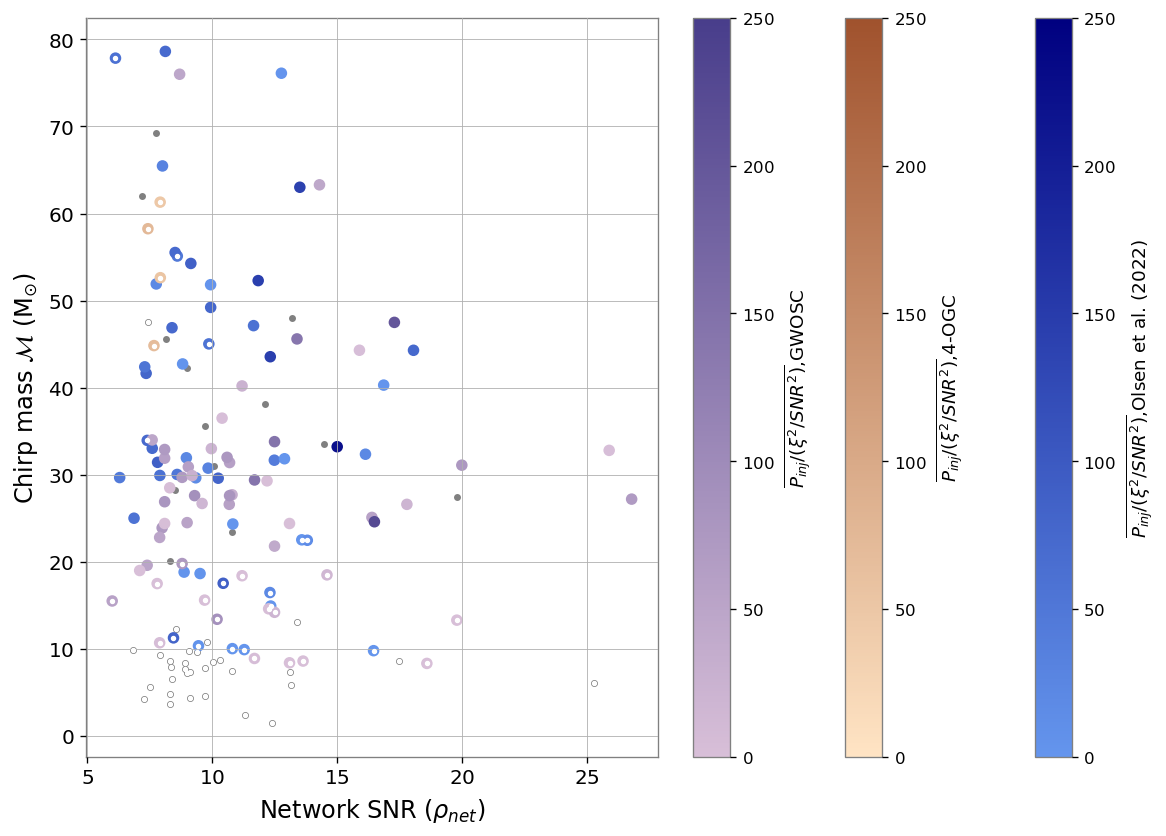

In [349]:
cmap1 = LinearSegmentedColormap.from_list(name='test', colors=['thistle', 'darkslateblue'])
cmap2 = LinearSegmentedColormap.from_list(name='test', colors=['bisque', 'sienna'])
cmap3 = LinearSegmentedColormap.from_list(name='test', colors=['cornflowerblue', 'navy'])
max_far = 1
fig = plt.figure(figsize=(12, 8), dpi=120)
plt.scatter(catalog['SNR'], catalog['Chirp mass'], c='grey', s=10)
plt.scatter(catalog[catalog['inHUll']=='p']['SNR'], catalog[catalog['inHUll']=='p']['Chirp mass'],
            c='white', s=5, zorder=10)

for cat in ['Princeton', 'Nitz', 'GWOSC']:
    tmp = catalog[(catalog['Catalog'] == cat)]
    far = tmp[['rank_stat_H1L1', 'rank_stat_H1V1', 'rank_stat_L1V1', 'rank_stat_H1L1V1']].min(axis=1)
    #far = far[far <= max_far]
    if cat == 'GWOSC': cmap, label = cmap1, 'GWOSC'
    if cat == 'Nitz': cmap, label = cmap2, '4-OGC'
    if cat  == 'Princeton':cmap, label = cmap3, 'Olsen et al. (2022)'
    plt.scatter(tmp['SNR'][far.index], tmp['Chirp mass'][far.index], c=far, s=35, cmap=cmap)
    

    cbar = plt.colorbar()
    cbar.set_label(r'$\overline{P_{inj}/(\xi^2/SNR^2)}$,' +label , fontsize=11)  # Adjust font size of label
    cbar.ax.tick_params(labelsize=10)  # Adjust font size of ticks

    plt.clim(0, 250)
    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $\mathcal{M}$ (M$_{\odot}$)')
    plt.savefig('rank_stat_grapes.pdf')

In [413]:
tmp = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/triggersHL_zero_lag_run_eq_match1_hlv.csv')

In [419]:
stat1 = tmp['Pinj_H1']/(tmp['Chisq_max_H1']/tmp['SNR_max_H1']**2)
stat2 = tmp['Pinj_L1']/(tmp['Chisq_max_L1']/tmp['SNR_max_L1']**2)
tmp['rank_stat'] = 3/(1/stat1+1/stat2+[0])

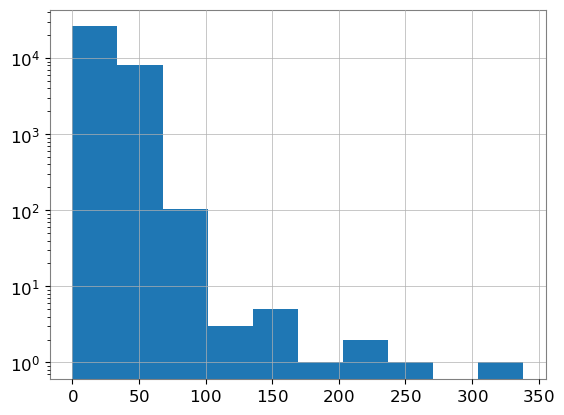

In [422]:
plt.hist(tmp['rank_stat'])
plt.yscale('log')

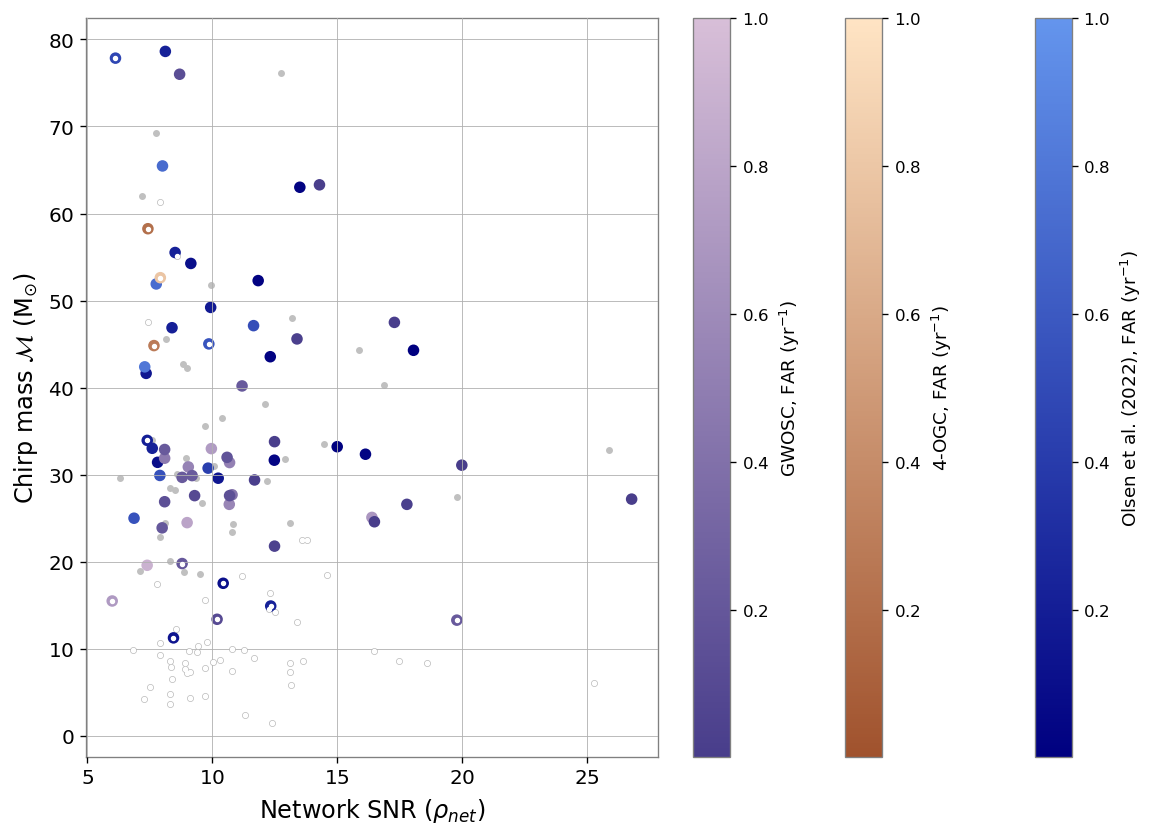

In [350]:
cmap1 = LinearSegmentedColormap.from_list(name='test', colors=['darkslateblue', 'thistle'])
cmap2 = LinearSegmentedColormap.from_list(name='test', colors=['sienna', 'bisque'])
cmap3 = LinearSegmentedColormap.from_list(name='test', colors=['navy', 'cornflowerblue'])
max_far = 1
fig = plt.figure(figsize=(12, 8), dpi=120)
plt.scatter(catalog['SNR'], catalog['Chirp mass'], c='silver', s=10)
plt.scatter(catalog[catalog['inHUll']=='p']['SNR'], catalog[catalog['inHUll']=='p']['Chirp mass'],
            c='white', s=5, zorder=10)

for cat in ['Princeton', 'Nitz', 'GWOSC']:
    tmp = catalog[(catalog['Catalog'] == cat)]
    far = tmp[['FAR_new_H1L1', 'FAR_new_H1V1', 'FAR_new_L1V1', 'FAR_new_H1L1V1']].min(axis=1)
    far = far[far <= max_far]
    if cat == 'GWOSC': cmap, label = cmap1, 'GWOSC'
    if cat == 'Nitz': cmap, label = cmap2, '4-OGC'
    if cat  == 'Princeton':cmap, label = cmap3, 'Olsen et al. (2022)'
    plt.scatter(tmp['SNR'][far.index], tmp['Chirp mass'][far.index], c=far, s=35, cmap=cmap)
    

    cbar = plt.colorbar()
    cbar.set_label(label + r', FAR (yr$^{-1}$)', fontsize=11)  # Adjust font size of label
    cbar.ax.tick_params(labelsize=10)  # Adjust font size of ticks

    plt.clim(0.001, max_far)
    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $\mathcal{M}$ (M$_{\odot}$)')
    plt.savefig('FAR_grapes.pdf')

In [352]:
catalog['Name'].values

array(['GW190403_051519', 'GW190408_181802', 'GW190412',
       'GW190413_052954', 'GW190413_134308', 'GW190421_213856',
       'GW190424_180648', 'GW190425', 'GW190426_190642',
       'GW190503_185404', 'GW190512_180714', 'GW190513_205428',
       'GW190514_065416', 'GW190517_055101', 'GW190519_153544',
       'GW190521', 'GW190521_074359', 'GW190527_092055',
       'GW190602_175927', 'GW190620_030421', 'GW190630_185205',
       'GW190701_203306', 'GW190706_222641', 'GW190707_093326',
       'GW190708_232457', 'GW190719_215514', 'GW190720_000836',
       'GW190725_174728', 'GW190727_060333', 'GW190728_064510',
       'GW190731_140936', 'GW190803_022701', 'GW190805_211137',
       'GW190814', 'GW190828_063405', 'GW190828_065509',
       'GW190909_114149', 'GW190910_112807', 'GW190915_235702',
       'GW190916_200658', 'GW190917_114630', 'GW190924_021846',
       'GW190925_232845', 'GW190926_050336', 'GW190929_012149',
       'GW190930_133541', 'GW191103_012549', 'GW191105_143521',
    

In [ ]:
from matplotlib.ticker import StrMethodFormatter
for cat in ['GWOSC', 'Nitz', 'Princeton']:
    df1 = allcatalogs[allcatalogs['Catalog'] == cat]
    df2 = little_dogs[little_dogs['Catalog'] == cat]
    dh1 = df1[df1['inHUll'] == 'p']
    dh2 = df2[df2['inHUll'] == 'p']
    sel_cols = df2[['FAR_H1L1', 'FAR_H1V1', 'FAR_L1V1', 'FAR_H1L1V1']]#[selected_columns].min(axis=1)
    min_values = np.round(sel_cols.min(axis=1),3)
    min_columns = sel_cols.idxmin(axis=1)*10
    
    cmap = LinearSegmentedColormap.from_list(name='test', colors=['darkslateblue', 'plum'])
    fig = plt.figure(dpi=120)
    plt.scatter(df1['SNR'], df1['Chirp mass'], c='grey', s=1,alpha=0.8)
    plt.scatter(dh1['SNR'], dh1['Chirp mass'], s=35, color='grey',alpha=0.8, lw=0.5, marker=r'$\odot$', facecolors='none', edgecolors='grey')
  
    plt.scatter(dh2['SNR'], dh2['Chirp mass'],  s=80/20, marker='o', color='white', zorder=10)
    plt.scatter(df2['SNR'], df2['Chirp mass'], c=min_values, s=min_columns.str.len(), cmap=cmap, alpha=0.9)

    cbar = plt.colorbar(label =r'FAR yr$^{-1}$')

    cbar.ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.3f}'))
    plt.clim(0.001, 0.1)
    g1 = plt.scatter([],[], s=1, marker='o', color='silver')
    g3 = plt.scatter([],[], s=8*10, marker='o', color='silver')
    g4 = plt.scatter([],[], s=10*10, marker='o', color='silver')
    
    plt.legend((g1, g3, g4),
           ('Not detected', 'Double coincidence', 'Triple coincidence'),
           scatterpoints=1, fontsize=12,
           ncol=1, loc='upper right')
    plt.xlabel(r'Network SNR ($\rho_{net}$)'), plt.ylabel(r'Chirp mass $(\mathcal{M}$)')


In [ ]:
path_zero_lag = '/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/'

ifo, t_search = 'H1L1', 0.5
file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
tmp = pd.read_csv(path_zero_lag+file)
tmp['barPinj'] = Measure.harmonic2coinc(tmp['Pinj_'+ifo[:2]],
                                                        tmp['Pinj_'+ifo[2:]])
ifo1, ifo2 = ifo[:2], ifo[2:]
# tmp.rename(columns=lambda col: rename_columns(col, ifo1, ifo1.capitalize()), inplace=True)
# tmp.rename(columns=lambda col: rename_columns(col, ifo2, ifo2.capitalize()), inplace=True)
tmp = Measure.prob2stat(tmp, ifo[:2]+ifo[2:], col='barPinj')
tmp = tmp.sort_values(by='rank_stat_H1L1', ascending=False)


t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
xbkg_obs, ybkg_obs, p_star, ylabel = Measure.getFARandThreshold(bkg, ifo, t_bkg, t_search, FAR=0.001)
p_star

In [ ]:
plt.hist(bkg['rank_stat_'+ifo], histtype='step', bins=100, density=True)
plt.hist(tmp['rank_stat_'+ifo], histtype='step', bins=100, density=True)
plt.yscale('log')

In [ ]:
plt.hist(bkg['rank_stat_'+ifo]/(bkg['Chisq_max_H1']*bkg['Chisq_max_L1']), bins=100, histtype='step', density=True,)
plt.hist(tmp['rank_stat_'+ifo]/(tmp['Chisq_max_H1']*tmp['Chisq_max_L1']), bins=100, histtype='step', density=True,)
plt.yscale('log')


In [ ]:
select_tmp = tmp[tmp['rank_stat_H1L1'] >= p_star]

In [ ]:
plt.scatter( np.sqrt(select_tmp['SNR_max_H1']**2+ select_tmp['SNR_max_L1']**2), select_tmp['barPinj'])

In [ ]:
tmp_ = pd.read_csv('/data/gravwav/lopezm/Projects/GlitchBank/runs/zero_lag/triggersHLV_zero_lag_eq_match.csv')

In [ ]:
plt.hist(tmp_['rank_stat_H1L1V1'], bins=100)
plt.yscale('log')

In [ ]:
tmp_[['Prob_0_L1', 'Prob_1_L1', 'Prob_2_L1', 'Prob_3_L1', 'Prob_4_L1']].head(5)

In [ ]:
tmp_[['Prob_0_H1', 'Prob_1_H1', 'Prob_2_H1', 'Prob_3_H1', 'Prob_4_H1']].head(5)

In [ ]:
tmp_[['Pinj_H1', 'Pinj_L1']].head(5)

In [ ]:
t_star = 1251286995
delta = 1
ranking = tmp[(tmp['Cluster time old_H1'] >= t_star - delta) & (tmp['Cluster time old_H1'] <= t_star + delta)]['rank_stat_' + ifo].values[0]

In [ ]:
dp = DataProcessor(path + 'computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/', path + 'runs/zero_lag/', path + 'runs/injections')

dH1, dH1_c = dp.LoadZeroLag('h1', reset=True)

In [ ]:
dH1.columns[12:]

# Add suffix to these columns
dH1_ = dH1.rename(columns={col: f"{col}_max" for col in dH1.columns[14:]})


In [ ]:
dH1_